In [1]:
import langchain
print(langchain.__version__)

1.3.14


In [2]:
import pandas as pd
import re
from langchain_core.documents import Document
import textwrap

# =========================
# LOAD CSV FILES
# =========================
df_penyakit = pd.read_csv("./Indonesian Pharmaceutical/Disease/processed_data_penyakit.csv")
df_obat = pd.read_csv("./Indonesian Pharmaceutical/Drug/processed_data_obat.csv")

# =========================
# TEXT CLEANING FUNCTION
# =========================
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove duplicated spaces/newlines
    text = re.sub(r"\s+", " ", text)

    # Remove repeated words (simple duplicate cleanup)
    text = re.sub(r"\b(\w+)( \1\b)+", r"\1", text, flags=re.IGNORECASE)

    # Some of the words are connected, put a space between them
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)

    return text.strip()

# =========================
# TRANSFORM DISEASE DATA
# =========================
disease_documents = []

for _, row in df_penyakit.iterrows():

    nama = clean_text(row.get("Nama Penyakit", ""))
    deskripsi = clean_text(row.get("Deskripsi Penyakit", ""))
    penyebab = clean_text(row.get("Penyebab Penyakit", ""))
    gejala = clean_text(row.get("Gejala Penyakit", ""))

    content = textwrap.dedent(f"""\
        [TITLE]
        {nama}

        [TYPE]
        Disease

        [DESCRIPTION]
        {deskripsi}

        [CAUSES]
        {penyebab}

        [SYMPTOMS]
        {gejala}
    """)

    disease_documents.append(
        Document(
            page_content=content,
            metadata={
                "source": "processed_data_penyakit.csv",
                "type": "disease",
                "name": nama
            }
        )
    )

# =========================
# TRANSFORM MEDICINE DATA
# =========================
medicine_documents = []

for _, row in df_obat.iterrows():

    nama = clean_text(row.get("Nama Obat", ""))
    deskripsi = clean_text(row.get("Deskripsi Obat", ""))
    indikasi = clean_text(row.get("Peringatan Sebelum Mengonsumsi Obat", ""))
    dosis = clean_text(row.get("Dosis dan Aturan Pakai Obat", ""))
    efek_samping = clean_text(row.get("Efek Samping dan Bahaya Obat", ""))

    content = textwrap.dedent(f"""\
                [TITLE]
                {nama}

                [TYPE]
                Medicine

                [DESCRIPTION]
                {deskripsi}

                [INDICATIONS]
                {indikasi}

                [DOSAGE]
                {dosis}

                [SIDE_EFFECTS]
                {efek_samping}
                """)

    medicine_documents.append(
        Document(
            page_content=content,
            metadata={
                "source": "processed_data_obat.csv",
                "type": "medicine",
                "name": nama
            }
        )
    )

# =========================
# COMBINE ALL DOCUMENTS
# =========================
all_documents = disease_documents + medicine_documents

print(f"Total documents: {len(all_documents)}")

# =========================
# OPTIONAL: PREVIEW
# =========================
print("\n===== SAMPLE DOCUMENT =====\n")
print(all_documents[3400].page_content)
print("\nMetadata:", all_documents[3400].metadata)

max_len = max(len(doc.page_content) for doc in all_documents)

Total documents: 3530

===== SAMPLE DOCUMENT =====

[TITLE]
Antikonvulsan

[TYPE]
Medicine

[DESCRIPTION]
Antikonvulsan atau antikejang adalah obat untuk mencegah dan mengatasi kejang, misalnya pada epilepsi. Di Indonesia, antikonvulsan tersedia dalam bentuk obat minum, suntik, dan enema.

[INDICATIONS]
Peringatan Sebelum Mengonsumsi Antikonvulsan hanya boleh digunakan sesuai resep dokter. Sebelum menggunakan antikonvulsan, ada beberapa hal yang harus Anda perhatikan, yaitu: Jangan menggunakan obat antikonvulsan jika Anda alergi terhadap obat ini.

[DOSAGE]
dosis, mengganti jenis obat, dan memulai atau menghentikan konsumsi obat antikonvulsan tanpa berkonsultasi ke dokter terlebih dahulu. Hal ini dapat menyebabkan kejang kembali muncul atau memburuk.

[SIDE_EFFECTS]
efek samping. Beri tahu dokter jika Anda sedang hamil, mungkin hamil, atau menyusui. Konsultasikan ke dokter mengenai alat kontrasepsi yang paling efektif selama menjalani pengobatan dengan obat ini. Segera konsultasikan ke

Test Dataset

In [3]:
import pandas as pd
import os

if not os.path.exists("medDataset_symptoms_treatment.csv"):
    df = pd.read_csv("hf://datasets/keivalya/MedQuad-MedicalQnADataset/medDataset_processed.csv")
    filtered = df[(df['qtype'] == 'symptoms') | (df['qtype'] == 'treatment')]
    filtered.to_csv("medDataset_symptoms_treatment.csv", index=False)
    print(f"Saved {len(filtered)} rows to medDataset_symptoms_treatment.csv")

In [4]:
import os
import torch
from langchain_ollama import ChatOllama
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

from sentence_transformers import CrossEncoder
from langchain_text_splitters import RecursiveCharacterTextSplitter 

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# CREATE EMBEDDINGS OR USE EXISTING EMBEDDING

EMBED_MODEL = "BAAI/bge-m3"
RERANKER_MODEL = "BAAI/bge-reranker-v2-m3"

embeddings = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    model_kwargs={
        "device": device,
    },
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 32 
    },
)
print("Embedding Model loaded")

persist_dir = "chroma_store"

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    separators=["\n\n", "\n", ". ", " ", ""]
)

if os.path.isdir(persist_dir) and os.listdir(persist_dir):
    print("Loading existing vector store...")
    vectordb = Chroma(persist_directory=persist_dir, embedding_function=embeddings)
    split_docs = text_splitter.split_documents(all_documents)
else:
    print("No existing store found. Splitting and embedding documents...")
    
    split_docs = text_splitter.split_documents(all_documents)
    print(f"Original lines: {len(all_documents)} -> Chunks: {len(split_docs)}")
    
    vectordb = Chroma.from_documents(
        documents=split_docs,
        embedding=embeddings,
        persist_directory=persist_dir,
    )
    print("Embedding complete and saved to disk.")

# INITIALIZE RETRIEVER
dense_retriever = vectordb.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 8}
)

bm25_retriever = BM25Retriever.from_documents(split_docs)

bm25_retriever.k = 8

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.5, 0.5]
)

reranker = CrossEncoder(
    RERANKER_MODEL,
    device=device
)

def retrieve_and_rerank(query, top_k=3):
    docs = ensemble_retriever.invoke(query)

    pairs = [[query, doc.page_content] for doc in docs]

    scores = reranker.predict(pairs)

    scored_docs = sorted(
        zip(docs, scores),
        key=lambda x: x[1],
        reverse=True
    )

    top_docs = [doc for doc, _ in scored_docs[:top_k]]

    return top_docs

c:\Users\ALIN\miniconda3\envs\rm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 40516.17it/s]


Embedding Model loaded
Loading existing vector store...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 7345.34it/s]


In [5]:
MODEL_NAME = "qwen3.5:4b"
EVALUATOR_MODEL_NAME = "gemma4:31b-cloud"

rag_llm = ChatOllama(
    model=MODEL_NAME,
    keep_alive=-1,
    temperature=0,
)
print("RAG LLM loaded")

rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a medical researcher. "
            "Use the retrieved context as the primary evidence for answering."
            "1. Answer the question in English. "
            "2. If the answer is not in the context, you MUST reply with 'I don't know' "
            "3. Be concise (max 2-3 sentences). "
            "4. Do not use your own internal medical knowledge."
        ),
        (
            "human",
            "Question: {question}\n\nContext:\n{context}",
        ),
    ]
)

no_rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system", 
            "You are a medical assistant. "
            "Answer the following question based purely on your general internal knowledge. "
            "Be concise (max 2-3 sentences). "
            "If you are unsure of the medical facts, you MUST reply with the exact phrase: 'I do not have enough information to answer this reliably.'"
        ),
        (
            "human",
            "Question: {question}", 
        ),
    ]
)

def format_docs(docs):
    parts = []
    for d in docs:
        meta = d.metadata or {}
        header = (
            "[SOURCE]\n"
            f"name: {meta.get('name', '')}\n"
            f"type: {meta.get('type', '')}\n"
            f"source: {meta.get('source', '')}\n"
        )
        parts.append(f"{header}\n{d.page_content}")
    return "\n\n".join(parts)

def ask_rag(question):
    docs = retrieve_and_rerank(question)
    context = format_docs(docs)
    answer = (rag_prompt | rag_llm | StrOutputParser()).invoke(
        {"question": question, "context": context}
    )
    sources = [d.metadata for d in docs]
    return {"answer": answer, "sources": sources}

def ask_no_rag(question):
    answer = (no_rag_prompt | rag_llm | StrOutputParser()).invoke(
        {"question": question}
    )
    
    return {"answer": answer, "sources": []}

def get_contexts(question):
    docs = retrieve_and_rerank(question)
    return [d.page_content for d in docs]

RAG LLM loaded


In [6]:
question = "What are the symptoms of flu?"

print("--- Running RAG ---")
rag_result = ask_rag(question)

print("--- Running No-RAG ---")
no_rag_result = ask_no_rag(question)

print(f"RAG Answer: {rag_result['answer']}\nSources: {rag_result['sources']}")
print(f"No-RAG Answer: {no_rag_result['answer']}")

--- Running RAG ---
--- Running No-RAG ---
RAG Answer: I don't know what the symptoms of flu are because they are not mentioned in the provided context. The text only discusses complications for Syndrome of Inappropriate Antidiuretic Hormone and Waham Kebesaran, such as coma or respiratory failure.
Sources: [{'name': 'Waham Kebesaran', 'type': 'disease', 'source': 'processed_data_penyakit.csv'}, {'source': 'processed_data_penyakit.csv', 'type': 'disease', 'name': 'Syndrome of Inappropriate Antidiuretic Hormone'}, {'source': 'processed_data_penyakit.csv', 'type': 'disease', 'name': 'Syndrome of Inappropriate Antidiuretic Hormone'}]
No-RAG Answer: Common flu symptoms typically include sudden onset fever, chills, cough, sore throat, runny or stuffy nose, muscle aches, and fatigue. Gastrointestinal issues like nausea may also occur in some individuals, particularly children.


In [7]:
import pandas as pd
import json
import os
from tqdm import tqdm
from ragas import EvaluationDataset

df_full = pd.read_csv("medDataset_symptoms_treatment.csv")

df_symptoms = df_full[df_full['qtype'] == 'symptoms'].sample(n=50, random_state=42)
df_treatments = df_full[df_full['qtype'] == 'treatment'].sample(n=50, random_state=42)

df_sampled = pd.concat([df_symptoms, df_treatments]).sample(frac=1, random_state=42)
eval_samples = df_sampled.to_dict('records')

print(f"Dataset Samples: {len(eval_samples)} total questions ({len(df_symptoms)} symptoms, {len(df_treatments)} treatments).")

OUTPUT_FILE = "qwen_rag_results.json"
records = []

if os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE, "r") as f:
        records = json.load(f)
    print(f"Resuming from record {len(records)}...")

for i in tqdm(range(len(records), len(eval_samples)), desc="Generating RAG vs No-RAG"):
    s = eval_samples[i]
    try:
        rag_result = ask_rag(s["Question"]) 
        
        norag_result = ask_no_rag(s["Question"])
        
        records.append({
            "user_input": s["Question"],
            "response": rag_result["answer"],         
            "norag_answer": norag_result["answer"], 
            "retrieved_contexts": get_contexts(s["Question"]), 
            "reference": s["Answer"],
        })
        
        if i % 10 == 0: 
            with open(OUTPUT_FILE, "w") as f:
                json.dump(records, f, indent=4)
                
    except Exception as e:
        print(f"Error at index {i}: {e}")
        continue

with open(OUTPUT_FILE, "w") as f:
    json.dump(records, f, indent=4)

print("FINISHED GENERATING BOTH DATASETS.")

Dataset Samples: 100 total questions (50 symptoms, 50 treatments).


Generating RAG vs No-RAG: 100%|██████████| 100/100 [9:12:35<00:00, 331.56s/it]  

FINISHED GENERATING BOTH DATASETS.


In [8]:
rag_dataset = EvaluationDataset.from_list(records)

norag_records = []

for r in records:
    norag_records.append({
        "user_input": r["user_input"],
        "response": r["norag_answer"], 
        "reference": r["reference"]    
    })

no_rag_dataset = EvaluationDataset.from_list(norag_records)

In [9]:
# # EVALUATION PHASE

# from openai import AsyncOpenAI
# from ragas.llms import llm_factory
# from ragas.cache import DiskCacheBackend
# from dotenv import load_dotenv

# load_dotenv()

# client = AsyncOpenAI(
#     base_url="http://localhost:11434/v1/",
#     api_key='ollama'
# )

# # client = AsyncOpenAI(
# #     base_url="https://openrouter.ai/api/v1",
# #     api_key=os.environ.get('OPENROUTER_API_KEY'),
# # )

# ragas_cache = DiskCacheBackend("./ragas_cache")

# evaluator_llm = llm_factory(
#     model=EVALUATOR_MODEL_NAME, 
#     client=client,
#     cache=ragas_cache,
#     temperature=0,
#     max_tokens=4096
# )

# import requests

# requests.post("http://localhost:11434/api/generate", 
#              json={"model": EVALUATOR_MODEL_NAME, "keep_alive": -1})

# print("Evaluator LLM loaded successfully")

# from ragas.embeddings import LangchainEmbeddingsWrapper

# ragas_emb = LangchainEmbeddingsWrapper(embeddings)

# print("Embedding model loaded successfully")

In [10]:
import os
import requests
from dotenv import load_dotenv

from langchain_ollama import ChatOllama
# Alternatively, using ChatOpenAI configured for Ollama:
# from langchain_openai import ChatOpenAI

from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

load_dotenv()

# 1. Warm up the model in Ollama
EVALUATOR_MODEL_NAME = "gemma4:31b-cloud"  # Replace with your model name
result = requests.post(
    "http://localhost:11434/api/generate", 
    json={"model": EVALUATOR_MODEL_NAME, "keep_alive": -1}
)
print(result.status_code)
print(result.text)

# 2. Initialize the LangChain LLM pointing to Ollama
raw_llm = ChatOllama(
    model=EVALUATOR_MODEL_NAME,
    base_url="http://localhost:11434",
    temperature=0
)

# 3. Wrap for Ragas
evaluator_llm = LangchainLLMWrapper(raw_llm)
ragas_emb = LangchainEmbeddingsWrapper(embeddings)

print("Evaluator LLM and Embeddings loaded successfully!")

200
{"model":"gemma4:31b","created_at":"2026-07-29T22:38:24.243753684Z","response":"","done":true,"done_reason":"load"}

Evaluator LLM and Embeddings loaded successfully!


C:\Users\ALIN\AppData\Local\Temp\ipykernel_1812\3495550211.py:31: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  evaluator_llm = LangchainLLMWrapper(raw_llm)
C:\Users\ALIN\AppData\Local\Temp\ipykernel_1812\3495550211.py:32: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_emb = LangchainEmbeddingsWrapper(embeddings)


In [11]:
from ragas.metrics import (
    Faithfulness, 
    AnswerRelevancy, 
    ContextPrecision, 
    ContextRecall,
    AnswerCorrectness
)

In [12]:
from ragas.run_config import RunConfig

f = Faithfulness(llm=evaluator_llm)
ar = AnswerRelevancy(llm=evaluator_llm, embeddings=ragas_emb, strictness=1)
cp = ContextPrecision(llm=evaluator_llm)
cr = ContextRecall(llm=evaluator_llm)
ac = AnswerCorrectness(llm=evaluator_llm, embeddings=ragas_emb)

run_config = RunConfig(max_workers=1, timeout=180)

In [13]:
from ragas import aevaluate
import pandas as pd

async def run_evals_in_batches(batch_size=10):
    print("Starting Evaluations in Batches...")
    
    rag_data = rag_dataset.to_list()
    norag_data = no_rag_dataset.to_list()
    
    all_rag_results = []
    all_norag_results = []
    
    print(f"\nProcessing RAG dataset ({len(rag_data)} samples) in batches of {batch_size}...")
    for i in range(0, len(rag_data), batch_size):
        batch = rag_data[i:i+batch_size]
        batch_dataset = EvaluationDataset.from_list(batch)
        
        print(f"  Batch {i//batch_size + 1}/{(len(rag_data)-1)//batch_size + 1} (samples {i}-{min(i+batch_size, len(rag_data))})")
        
        batch_results = await aevaluate(
            dataset=batch_dataset,
            metrics=[f, ar, cp, cr, ac],
            run_config=run_config,
        )
        
        all_rag_results.append(batch_results.to_pandas())
    
    print(f"\nProcessing No-RAG dataset ({len(norag_data)} samples) in batches of {batch_size}...")
    for i in range(0, len(norag_data), batch_size):
        batch = norag_data[i:i+batch_size]
        batch_dataset = EvaluationDataset.from_list(batch)
        
        print(f"  Batch {i//batch_size + 1}/{(len(norag_data)-1)//batch_size + 1} (samples {i}-{min(i+batch_size, len(norag_data))})")
        
        batch_results = await aevaluate(
            dataset=batch_dataset,
            metrics=[ar, ac],
            run_config=run_config,
        )
        
        all_norag_results.append(batch_results.to_pandas())
    
    results_rag_combined = pd.concat(all_rag_results, ignore_index=True)
    results_norag_combined = pd.concat(all_norag_results, ignore_index=True)
    
    return results_rag_combined, results_norag_combined

results_rag, results_norag = await run_evals_in_batches(batch_size=10)

print("All batch evaluations complete!")

Starting Evaluations in Batches...

Processing RAG dataset (100 samples) in batches of 10...
  Batch 1/10 (samples 0-10)


Evaluating: 100%|██████████| 50/50 [08:56<00:00, 10.74s/it]


  Batch 2/10 (samples 10-20)


Evaluating: 100%|██████████| 50/50 [07:37<00:00,  9.16s/it]


  Batch 3/10 (samples 20-30)


...

  Batch 9/10 (samples 80-90)


Evaluating: 100%|██████████| 20/20 [05:15<00:00, 15.77s/it]


  Batch 10/10 (samples 90-100)


Evaluating: 100%|██████████| 20/20 [03:55<00:00, 11.79s/it]

All batch evaluations complete!


In [14]:
results_rag.to_csv('experiments/qwen_rag_eval.csv', index=False)

In [15]:
results_norag.to_csv('experiments/qwen_norag_eval.csv', index=False)

In [16]:
print(results_rag.columns)
print(results_norag.columns)

Index(['user_input', 'retrieved_contexts', 'response', 'reference',
       'faithfulness', 'answer_relevancy', 'context_precision',
       'context_recall', 'answer_correctness'],
      dtype='str')
Index(['user_input', 'response', 'reference', 'answer_relevancy',
       'answer_correctness'],
      dtype='str')


In [17]:
# RAG metrics
print("=== RAG ===")
rag_metrics = results_rag[['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall', 'answer_correctness']]
print(rag_metrics.mean())

# No-RAG metrics
print("=== NO RAG ===")
norag_metrics = results_norag[['answer_relevancy', 'answer_correctness']]
print(norag_metrics.mean())

=== RAG ===
faithfulness          0.693297
answer_relevancy      0.101048
context_precision     0.352500
context_recall        0.017885
answer_correctness    0.173919
dtype: float64
=== NO RAG ===
answer_relevancy      0.598539
answer_correctness    0.278530
dtype: float64


In [18]:
# CSV Metrics only
results_rag[['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall', 'answer_correctness']].to_csv('experiments/qwen_rag_eval_metrics.csv', index=False)
results_norag[['answer_relevancy', 'answer_correctness']].to_csv('experiments/qwen_norag_eval_metrics.csv', index=False)

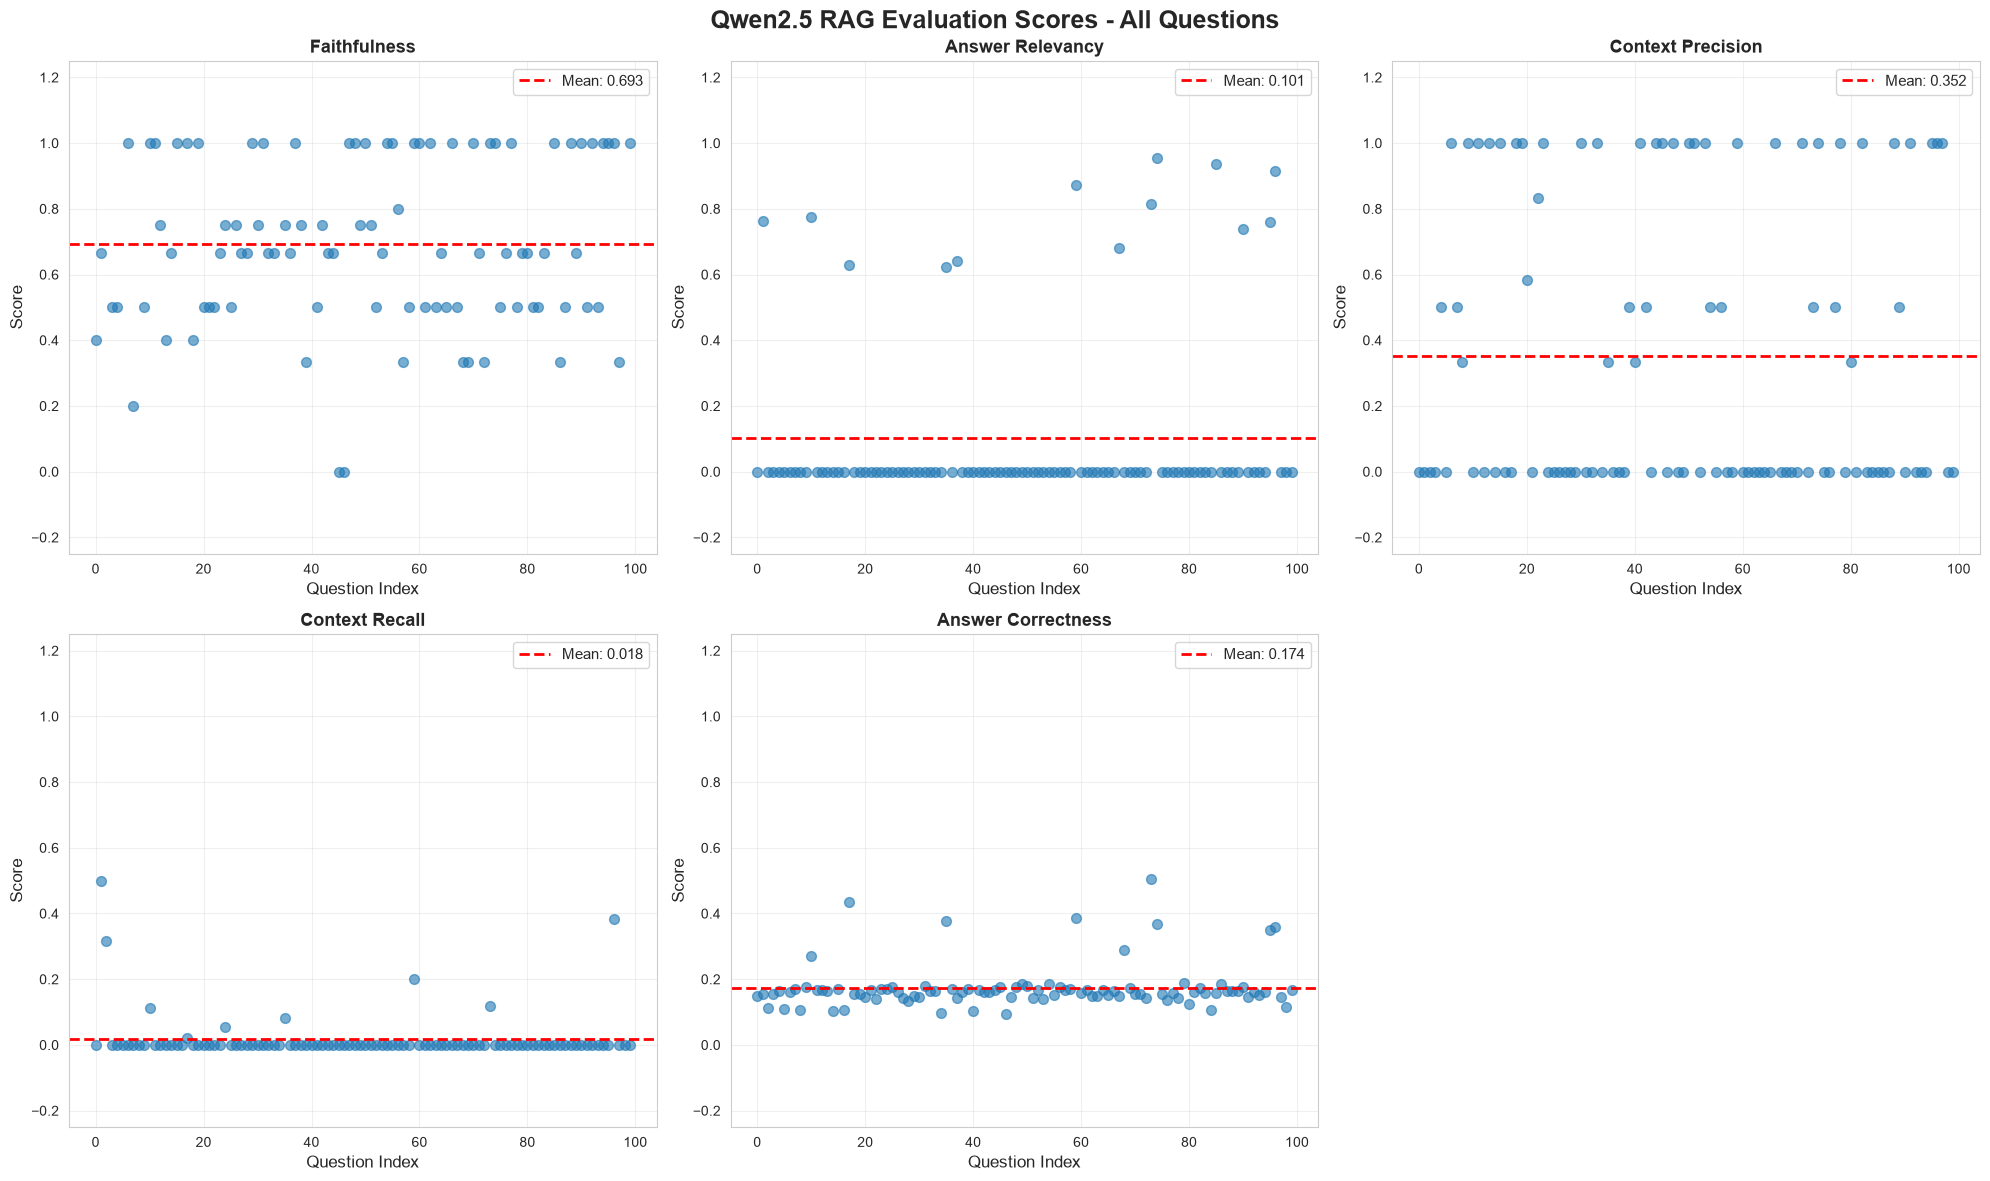

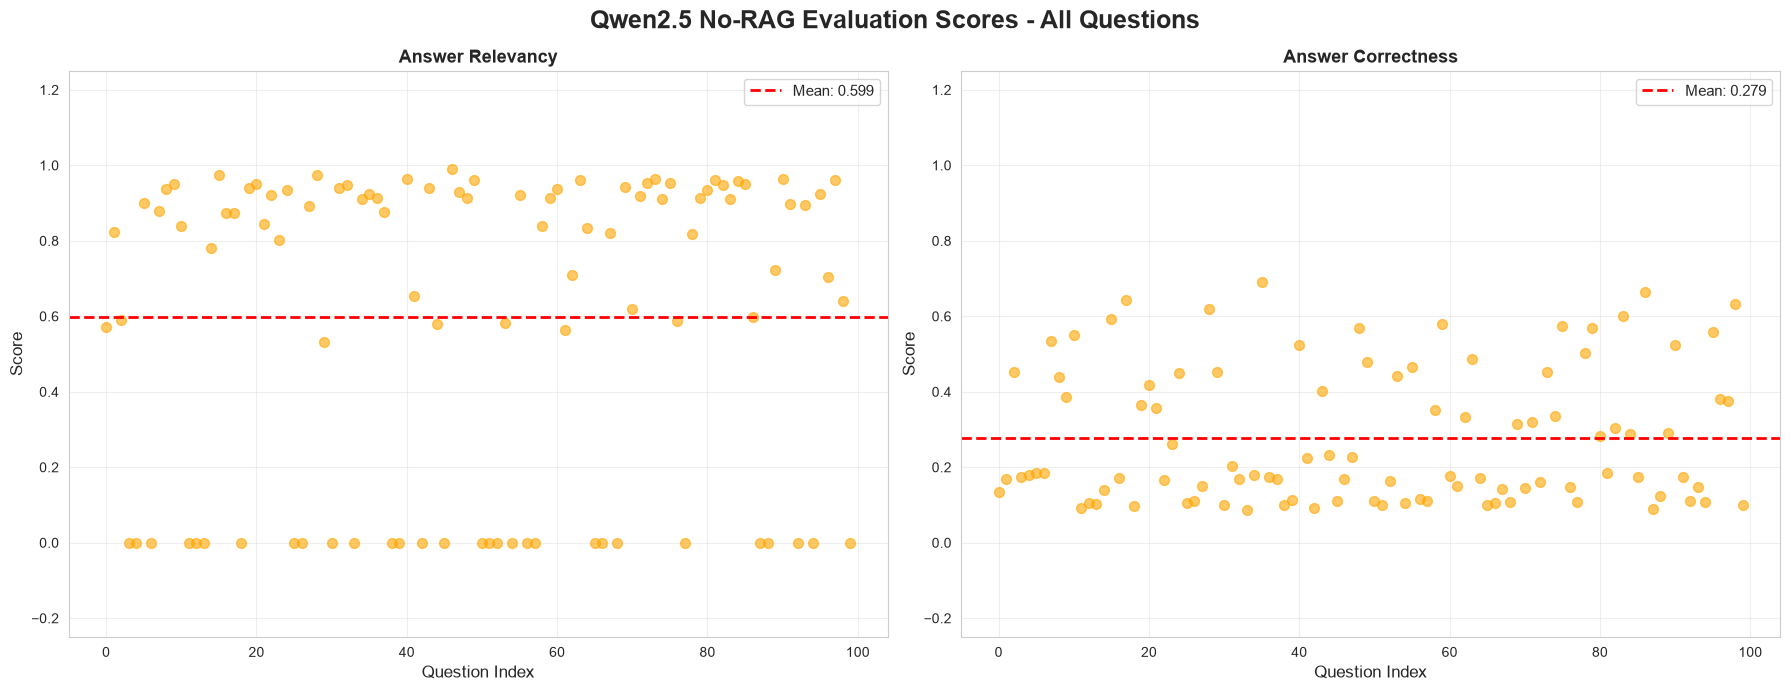

Plots saved to experiments/


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ===== RAG PLOTS =====
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Qwen2.5 RAG Evaluation Scores - All Questions', fontsize=18, fontweight='bold')

rag_cols = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall', 'answer_correctness']

for idx, col in enumerate(rag_cols):
    ax = axes[idx // 3, idx % 3]
    ax.scatter(range(len(results_rag)), results_rag[col], alpha=0.6, s=50)
    ax.axhline(y=results_rag[col].mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {results_rag[col].mean():.3f}')
    ax.set_xlabel('Question Index', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(col.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_ylim(-0.25, 1.25)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('experiments/qwen_rag_scores_all_questions.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== NO-RAG PLOTS =====
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Qwen2.5 No-RAG Evaluation Scores - All Questions', fontsize=18, fontweight='bold')

norag_cols = ['answer_relevancy', 'answer_correctness']

for idx, col in enumerate(norag_cols):
    ax = axes[idx]
    ax.scatter(range(len(results_norag)), results_norag[col], alpha=0.6, s=50, color='orange')
    ax.axhline(y=results_norag[col].mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {results_norag[col].mean():.3f}')
    ax.set_xlabel('Question Index', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(col.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_ylim(-0.25, 1.25)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiments/qwen_norag_scores_all_questions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plots saved to experiments/")

Visualization Revision

Loaded results_rag from experiments/qwen_rag_eval.csv (rows=100)
Loaded results_norag from experiments/qwen_norag_eval.csv (rows=100)


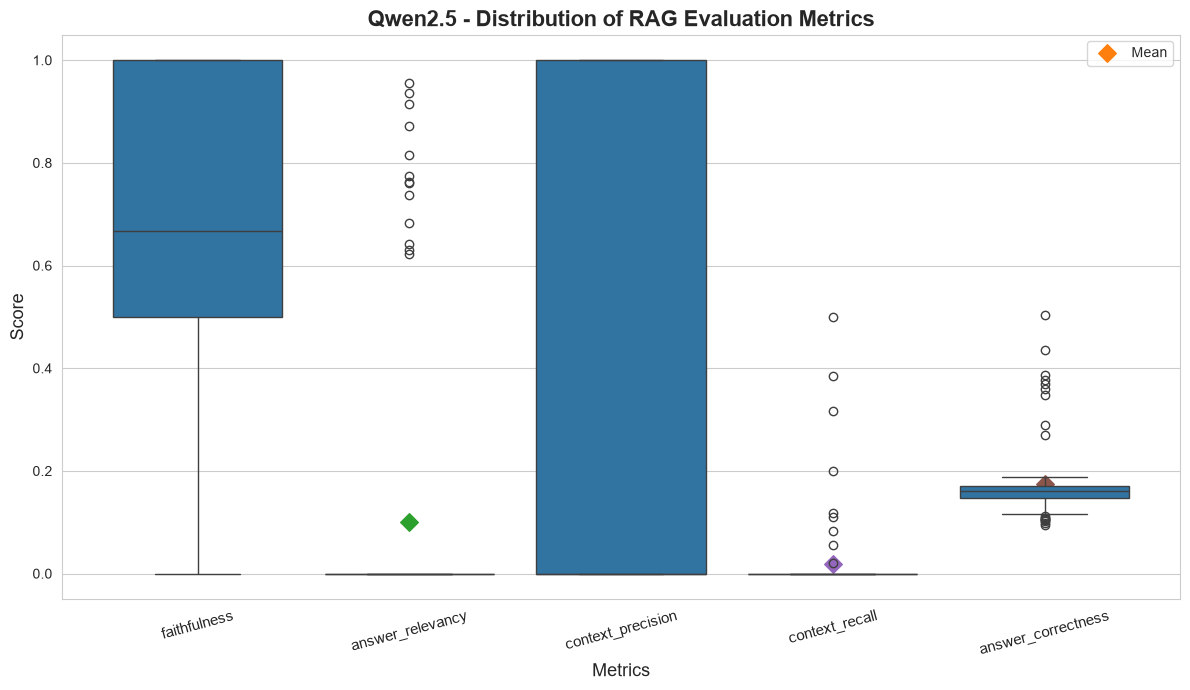

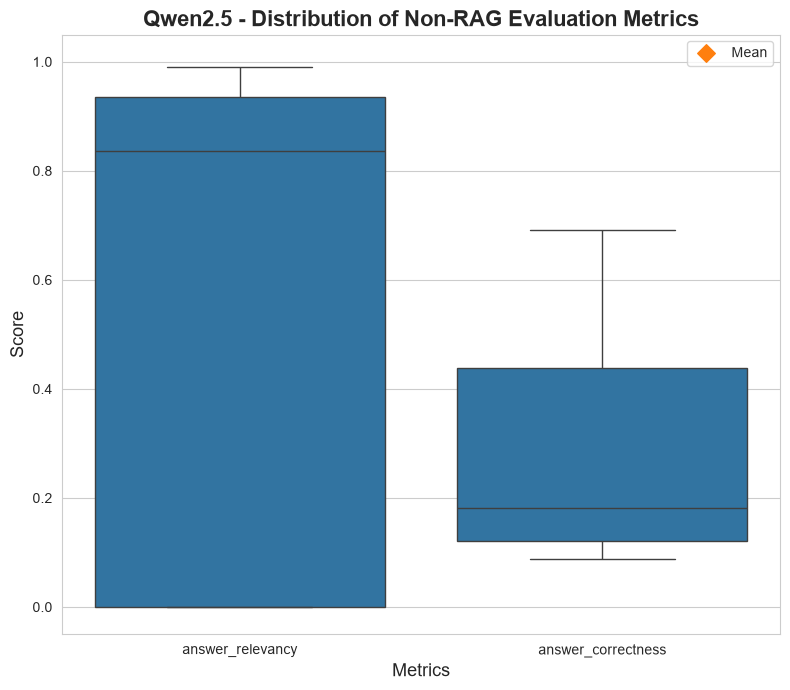

Box plots saved to experiments/


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")


results_rag = pd.read_csv('experiments/qwen_rag_eval.csv')
print(f"Loaded results_rag from experiments/qwen_rag_eval.csv (rows={len(results_rag)})")

results_norag = pd.read_csv('experiments/qwen_norag_eval.csv')
print(f"Loaded results_norag from experiments/qwen_norag_eval.csv (rows={len(results_norag)})")

# =========================================
# RAG BOXPLOT
# =========================================

rag_cols = [
    'faithfulness',
    'answer_relevancy',
    'context_precision',
    'context_recall',
    'answer_correctness'
]

# Convert to long format
rag_long = results_rag[rag_cols].melt(
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    data=rag_long,
    x='Metric',
    y='Score'
)

# Add mean points
means = results_rag[rag_cols].mean().values

for i, mean in enumerate(means):
    plt.scatter(i, mean, marker='D', s=80, label='Mean' if i == 0 else "")

plt.title(
    'Qwen2.5 - Distribution of RAG Evaluation Metrics',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Metrics', fontsize=13)
plt.ylabel('Score', fontsize=13)

plt.xticks(
    rotation=15,
    fontsize=11
)

plt.ylim(-0.05, 1.05)

plt.legend()
plt.tight_layout()

plt.savefig(
    'experiments/qwen_rag_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# =========================================
# NON-RAG BOXPLOT
# =========================================

norag_cols = [
    'answer_relevancy',
    'answer_correctness'
]

norag_long = results_norag[norag_cols].melt(
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(8, 7))

ax = sns.boxplot(
    data=norag_long,
    x='Metric',
    y='Score'
)

# Add mean points
means = results_norag[norag_cols].mean().values

for i, mean in enumerate(means):
    plt.scatter(i, mean, marker='D', s=80, label='Mean' if i == 0 else "")

plt.title(
    'Qwen2.5 - Distribution of Non-RAG Evaluation Metrics',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Metrics', fontsize=13)
plt.ylabel('Score', fontsize=13)

plt.ylim(-0.05, 1.05)

plt.legend()
plt.tight_layout()

plt.savefig(
    'experiments/qwen_norag_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Box plots saved to experiments/")

C:\Users\ALIN\AppData\Local\Temp\ipykernel_1812\50382458.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\ALIN\AppData\Local\Temp\ipykernel_1812\50382458.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(rag_labels)


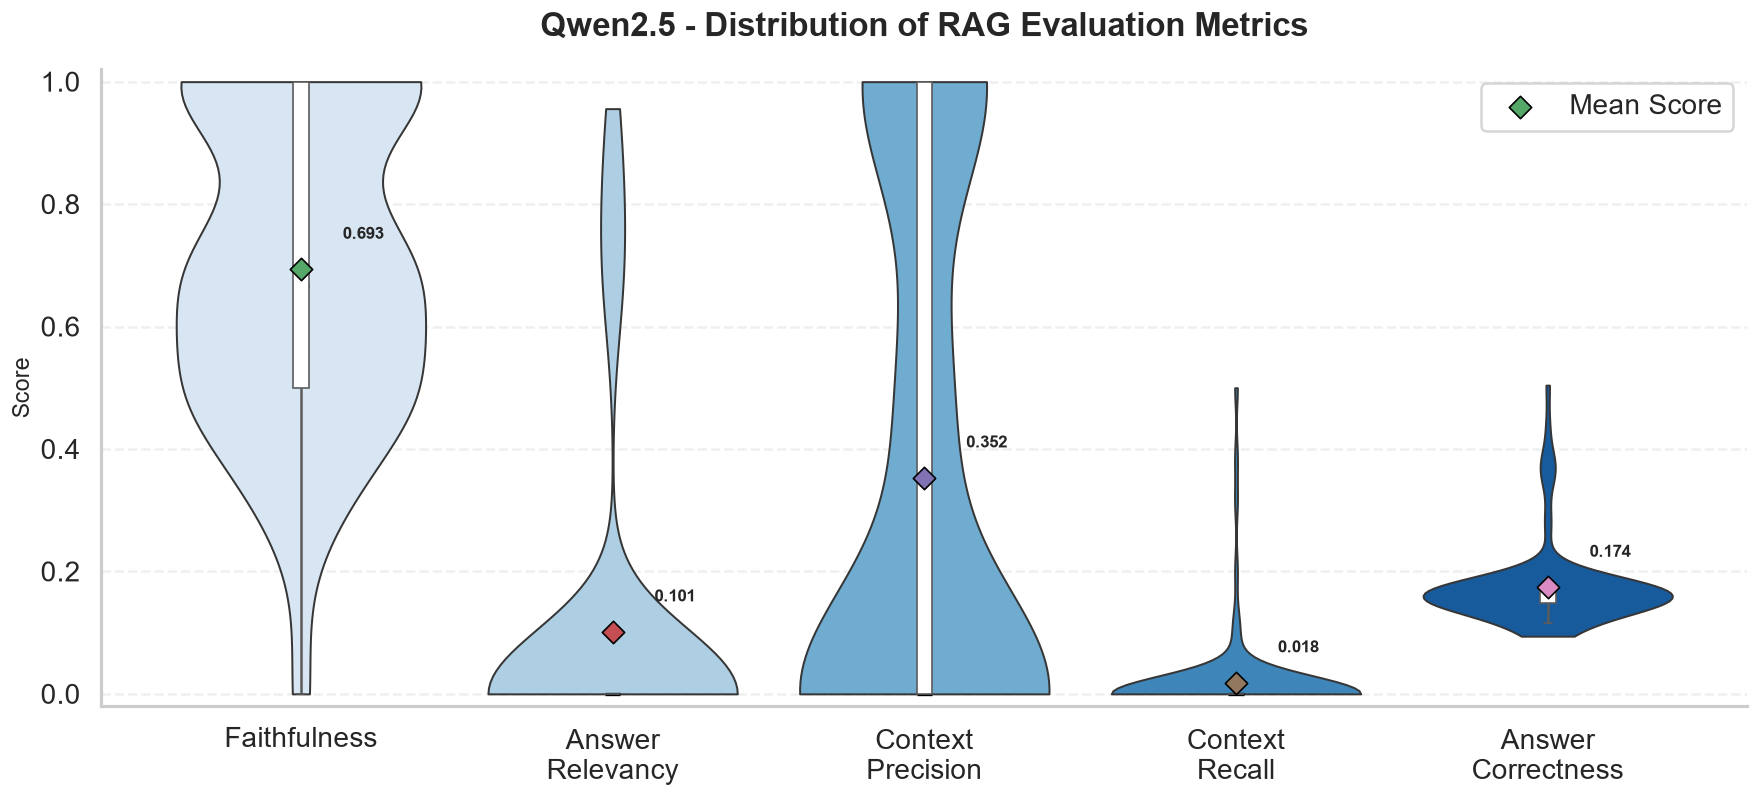

C:\Users\ALIN\AppData\Local\Temp\ipykernel_1812\50382458.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\ALIN\AppData\Local\Temp\ipykernel_1812\50382458.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(norag_labels)


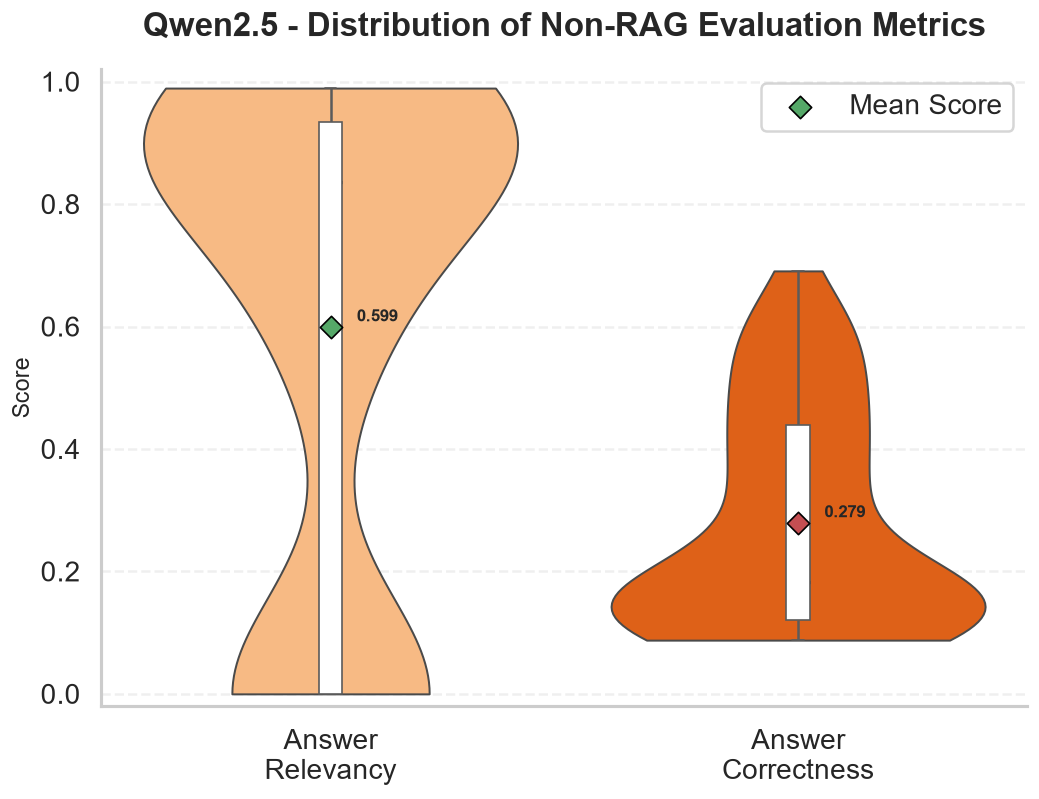

Pretty violin plots saved to experiments/


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =========================================
# GLOBAL STYLE
# =========================================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'

# Soft academic palette
rag_palette = sns.color_palette("Blues", 5)
norag_palette = sns.color_palette("Oranges", 2)

# =========================================
# RAG VIOLIN PLOT
# =========================================

rag_cols = [
    'faithfulness',
    'answer_relevancy',
    'context_precision',
    'context_recall',
    'answer_correctness'
]

rag_labels = [
    'Faithfulness',
    'Answer\nRelevancy',
    'Context\nPrecision',
    'Context\nRecall',
    'Answer\nCorrectness'
]

rag_long = results_rag[rag_cols].melt(
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(15, 7))

ax = sns.violinplot(
    data=rag_long,
    x='Metric',
    y='Score',
    palette=rag_palette,
    inner=None,
    linewidth=1.2,
    cut=0,
    saturation=0.9
)

# Overlay boxplot for quartiles
sns.boxplot(
    data=rag_long,
    x='Metric',
    y='Score',
    width=0.05,
    showcaps=True,
    boxprops={
        'facecolor': 'white',
        'zorder': 3
    },
    whiskerprops={'linewidth': 1.5},
    medianprops={
        'color': 'black',
        'linewidth': 2
    },
    showfliers=False
)

# Mean markers
means = results_rag[rag_cols].mean().values

for i, mean in enumerate(means):
    plt.scatter(
        i,
        mean,
        marker='D',
        s=90,
        edgecolor='black',
        linewidth=1,
        zorder=10,
        label='Mean Score' if i == 0 else ""
    )

# Mean value text
for i, mean in enumerate(means):
    plt.text(
        i + 0.20,
        mean + 0.05,
        f"{mean:.3f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xticklabels(rag_labels)

plt.title(
    'Qwen2.5 - Distribution of RAG Evaluation Metrics',
    fontsize=20,
    pad=20
)

plt.xlabel('')
plt.ylabel('Score', fontsize=14)

plt.ylim(-0.02, 1.02)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    frameon=True,
    fancybox=True
)

sns.despine(left=False, bottom=False)

plt.tight_layout()

plt.savefig(
    'experiments/qwen_rag_violinplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================
# NON-RAG VIOLIN PLOT
# =========================================

norag_cols = [
    'answer_relevancy',
    'answer_correctness'
]

norag_labels = [
    'Answer\nRelevancy',
    'Answer\nCorrectness'
]

norag_long = results_norag[norag_cols].melt(
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(9, 7))

ax = sns.violinplot(
    data=norag_long,
    x='Metric',
    y='Score',
    palette=norag_palette,
    inner=None,
    linewidth=1.2,
    cut=0,
    saturation=0.9
)

sns.boxplot(
    data=norag_long,
    x='Metric',
    y='Score',
    width=0.05,
    showcaps=True,
    boxprops={
        'facecolor': 'white',
        'zorder': 3
    },
    whiskerprops={'linewidth': 1.5},
    medianprops={
        'color': 'black',
        'linewidth': 2
    },
    showfliers=False
)

means = results_norag[norag_cols].mean().values

for i, mean in enumerate(means):
    plt.scatter(
        i,
        mean,
        marker='D',
        s=90,
        edgecolor='black',
        linewidth=1,
        zorder=10,
        label='Mean Score' if i == 0 else ""
    )

for i, mean in enumerate(means):
    plt.text(
        i + 0.1,
        mean + 0.01,
        f"{mean:.3f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xticklabels(norag_labels)

plt.title(
    'Qwen2.5 - Distribution of Non-RAG Evaluation Metrics',
    fontsize=20,
    pad=20
)

plt.xlabel('')
plt.ylabel('Score', fontsize=14)

plt.ylim(-0.02, 1.02)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    frameon=True,
    fancybox=True
)

sns.despine(left=False, bottom=False)

plt.tight_layout()

plt.savefig(
    'experiments/qwen_norag_violinplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Pretty violin plots saved to experiments/")